BB84: Quantum Key Distribution  
This is a walk through of a simple implementation of the BB84 protocol for QKD. 
This note book walks through my implementation of the BB84 QKD protocol in current Qiskit.
It contains Alice (sender), Bob (receiver) and Eve (eavesdropper).
The evesdropper is an incerpet-resend and created a detecable disturance via the quanutm bit error rate (QBER)
My dissertion covered the theory of BB84 and E91 finishing on DI-QKD. The goal here was to further my understandiung by amking the theory executable  - every gate justified, every statistic checked against prediction.
The full implementation lives in protocols/, attacks/ and analysis/; this notebook imports it and demonstrates it stage by stage.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from protocols.bb84 import encode_qubit, measure_qubit, sift, qber, run_bb84

sim = AerSimulator() # create a simulator instance
rng = np.random.default_rng(42) # create a random number generator instance with a fixed seed for reproducibility

One qubit, two orthnormal bases
BB84 relies geavily on the one linear -algerbra fact that the Hadamard fate is a change of basis. It maps the compuational Z basis onto the diagonal X basis,  H|0⟩ = |+⟩ and H|1⟩ = |−⟩. Because H² = I, applying it a second time maps them back.
The gate itself is deterministic - |0⟩ becomes exactly |+⟩ every single time. The randomness only enters at measurement.
The Born rule gives P(outcome) = |amplitude|², so measuring |+⟩ in the Z basis is a fair coin: |⟨0|+⟩|^2 = 1/2.
The next cell shows both cases side by side: the same X-basis state measured in the wrong basis (random) and in the right basis (certain).

In [3]:
# Same X-basis state, measured in the wrong basis vs the right basis
qc_wrong = QuantumCircuit(1, 1); qc_wrong.h(0); qc_wrong.measure(0, 0) # creates a quanutm ciructe that prepares a qubit in the X-basis and measures it in the Z-basis
qc_right = QuantumCircuit(1, 1); qc_right.h(0); qc_right.h(0); qc_right.measure(0, 0) # creates a quantum circuit that prepares a qubit in the X-basis and measures it in the X-basis

for label, qc in [("Z-measure (orthogonal basis)", qc_wrong), ("X-measure (matching basis)", qc_right)]:
    counts = sim.run(transpile(qc, sim), shots=1000).result().get_counts()
    print(f"{label}: {counts}")

Z-measure (orthogonal basis): {'1': 500, '0': 500}
X-measure (matching basis): {'0': 1000}


When measuring using the orthnoal basis measurment splits roughly 50/50. The matching basis retunrs the encoded value 100% of the time, because Bob's Hadamard undoes Alice's (H² = I) and the state hitting the detector is exactly |1⟩ - the Born rule then gives probability 1, not a coin flip.
This asymmetry is the entire security mechanism of BB84: deterministic in the matching basis, uniformly random in the mismatched one. Anyone who measures without knowing the basis destroys information and leaves statistical fingerprints. The rest of the notebook is about making those fingerprints visible.


In [4]:
alice_key, bob_key, error_rate = run_bb84(n=100, eve_fraction=0.0) # run the BB84 protocol with 100 qubits and no eavesdropping
print("first 20 of Alice's key:", alice_key[:20])
print("first 20 of Bob's key:  ", bob_key[:20])

eve_fraction=0.00 | sent 100 | sifted 51 | QBER 0.000
first 20 of Alice's key: [0 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 0]
first 20 of Bob's key:   [0 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 0]


Post Clean Run - The protocol on a clean channel.
Alice Sent n=100 qubits, each hold a random bit value and are prepared in a random basis; Bob measures each in his own radnom basis. They then only comapre bases - never bit values - and keep all mathcing rounds. This is all done over a public channe. For this simple implemetneation - noise and attacker free roughly 50% of the rounds shoudl be used for a key (where the distibution is Binomial(100, 1/2)). At every surviving position Bob's and Alice's basis match so the outcome is deterministic: there is no eaves dropper so the keys will match exactly. The timing of that public comapriosn matters. Bases are annonced only after the qubits are measured - announced earlier, an eaves dropper could over hear and go undetected by knowing the correct opertion so it goes undetected. Withholding the bases is what forces any attacker to guess and what makes Bob's choicee random and not openly predetermined.

In [5]:
alice_key, bob_key, error_rate = run_bb84(n=100, eve_fraction=1.0) # run the BB84 protocol with 100 qubits and full eavesdropping
print("first 20 of Alice's key:", alice_key[:20])   
print("first 20 of Bob's key:  ", bob_key[:20])

eve_fraction=1.00 | sent 100 | sifted 48 | QBER 0.292
first 20 of Alice's key: [1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1]
first 20 of Bob's key:   [1 1 1 0 1 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1]


Post Eavesdropper
Run Eve meaures each intercept qubit in a randomly guessed basis and forwards a fresh qubit prepared as what ever she saw. That is her best option as no-cloning theorem states that no unkown argibraty qubit can be copied using any operator U - a two line consequnce of linearity. She can therefore not keep a copied orginal to measure from freely. 3 Independent events need to allign to corrupted sifted bit (Qunautm Bit Error): P(error) = rate of incerception × P(Eve guesses wrong basis) × P(Bob's outcome flips) = r × 1/2 × 1/2 = r/4. When r = 1, eve intercepts 100% of the qubits and he QBER is therofore ~25% - visable above where the keys disagree at rougly a quater of positsions even though Alice's and Bob's bases matched at every one of them.

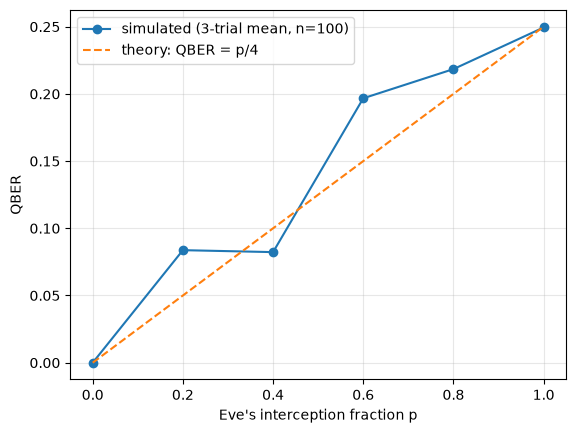

In [6]:
fractions = np.linspace(0, 1, 6)   # coarser than analysis/qber_plots.py: notebook speed
trials, n = 3, 100
means = [np.mean([run_bb84(n=n, eve_fraction=p, verbose=False)[2] for _ in range(trials)])
         for p in fractions]

plt.plot(fractions, means, "o-", label=f"simulated ({trials}-trial mean, n={n})")
plt.plot(fractions, fractions/4, "--", label="theory: QBER = p/4")
plt.xlabel("Eve's interception fraction p"); plt.ylabel("QBER")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Close
Detection, not prevention The sweep confirms QBER ≈ p/4 across interception fractions. One statistical caveat belongs alongside it: on a ~50-bit sifted key, the sd σ = √(q(1−q)/N) ≈ 0.06. Separating a real deviation from noise at 3σ takes on the order of a thousand sifted bits. Estimating the QBER costs key material - that trade is built into real QKD systems. Estimating the QBER costs key material, as you need to reveal some bits which are then discarded - that trade is built into real QKD systems. 
That is also the right way to state what BB84 promises. It does not stop Eve from listening. It guarantees she cannot listen without disturbing the channel, and the disturbance is measurable. Alice and Bob either share a key she provably knows almost nothing about, or they abort having lost only qubits -  while Eve's partial transcript correlates with a key that no longer exists. The abort is the security working, not failing.
The full-resolution sweep (10 trials, n = 300, SEM error bars) is in analysis/qber_vs_eve.png. The next extension is E91 andd DI-QKD, where security comes from entanglement and a CHSH Bell-inequality violation instead of prepared states — the road that leads to the DI-QKD ideas my dissertation finished on.